# Практическая работа 1. Свёрточные нейронные сети

## Классификация изображений овощей (Vegetable Image Dataset)

**Выполнил(а):** _________________________  (Фамилия И. О.)

**Группа:** _____________

**Преподаватель:** _____________

---

Цель работы — разобраться с тем, как свёрточные нейронные сети решают задачу
классификации изображений. В качестве данных взят
[Vegetable Image Dataset](https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset/):
21000 фотографий, 15 видов овощей, разрешение 224×224, готовое разбиение на
обучающую, проверочную и тестовую части.

В работе обучаются две модели — собственная свёрточная сеть и предобученная
ResNet18. Сначала по проверочной выборке подбирается скорость обучения для сети
«с нуля», затем обе модели сравниваются на тестовой выборке. Реализация выполнена
на PyTorch и torchvision — это один из двух стеков, разрешённых заданием. Датасет
скачивается автоматически, поэтому ноутбук запускается без ручной подготовки
файлов.

## 1. Импорт библиотек и параметры запуска

In [1]:
import os
import time
import random
import shutil
import zipfile

import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
SEED = 42
IMG_SIZE = 224
BATCH = 64
LR_GRID = [3e-3, 1e-3, 3e-4]
EPOCHS_SEARCH = 2
EPOCHS_CNN = 8
EPOCHS_RESNET = 3
LR_RESNET = 1e-4
PRETRAINED = True
NUM_WORKERS = 2
DATASET_URL = "https://disk.yandex.ru/d/5y96DSryHU8Mag"
DATA_ROOT = "/content/vegetables" if os.path.isdir("/content") else os.path.abspath("./vegetables")

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__)
print("устройство:", device)

torch: 2.11.0+cu128
устройство: cuda


## 2. Загрузка набора данных

Датасет скачивается по публичной ссылке и распаковывается автоматически. Если данные уже распакованы, повторное скачивание не выполняется.

In [4]:
def fetch_href(public_url):
    api = "https://cloud-api.yandex.net/v1/disk/public/resources/download"
    resp = requests.get(api, params={"public_key": public_url}, timeout=60)
    resp.raise_for_status()
    data = resp.json()
    if "href" not in data:
        raise RuntimeError(f"Yandex.Disk не вернул ссылку на скачивание (возможен лимит обращений): {data}")
    return data["href"]


def download_dataset(public_url, dst_zip):
    href = fetch_href(public_url)
    tmp = dst_zip + ".part"
    with requests.get(href, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get("Content-Length", 0))
        done, step, nxt = 0, 100 << 20, 100 << 20
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
                done += len(chunk)
                if done >= nxt:
                    pct = (100.0 * done / total) if total else 0.0
                    print(f"скачано {done >> 20} МБ ({pct:.0f}%)")
                    nxt += step
    os.rename(tmp, dst_zip)


def find_data_dir(base):
    for root, dirs, _ in os.walk(base):
        if {"train", "validation", "test"}.issubset(set(dirs)):
            return root
    return None


def clean_service_dirs(base):
    for root, dirs, _ in os.walk(base):
        for d in list(dirs):
            if d in ("__MACOSX", ".ipynb_checkpoints"):
                shutil.rmtree(os.path.join(root, d), ignore_errors=True)


os.makedirs(DATA_ROOT, exist_ok=True)
zip_path = os.path.join(DATA_ROOT, "vegetables.zip")
DATA_DIR = find_data_dir(DATA_ROOT)

if DATA_DIR is None:
    for attempt in range(3):
        try:
            download_dataset(DATASET_URL, zip_path)
            break
        except Exception as e:
            print(f"попытка {attempt + 1} не удалась: {e}")
            for p in (zip_path, zip_path + ".part"):
                if os.path.exists(p):
                    os.remove(p)
    if not os.path.exists(zip_path):
        raise RuntimeError("Не удалось скачать датасет. Проверьте сеть или скачайте архив вручную по ссылке DATASET_URL.")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_ROOT)
    clean_service_dirs(DATA_ROOT)
    DATA_DIR = find_data_dir(DATA_ROOT)

if DATA_DIR is None:
    raise FileNotFoundError("После распаковки не найдены папки train/validation/test")

train_path = os.path.join(DATA_DIR, "train")
val_path = os.path.join(DATA_DIR, "validation")
test_path = os.path.join(DATA_DIR, "test")
print("каталог данных:", DATA_DIR)

скачано 100 МБ (18%)
скачано 200 МБ (37%)
скачано 300 МБ (55%)
скачано 400 МБ (74%)
скачано 500 МБ (92%)
каталог данных: /content/vegetables/Vegetable_Images


## 3. Предобработка и загрузчики

Изображения приводятся к размеру 224×224 и нормализуются по статистикам ImageNet. К обучающей выборке добавлены случайное отражение и небольшой поворот.

In [5]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder(train_path, transform=train_tf)
val_ds = datasets.ImageFolder(val_path, transform=eval_tf)
test_ds = datasets.ImageFolder(test_path, transform=eval_tf)

class_names = train_ds.classes
num_classes = len(class_names)
assert num_classes == 15, f"Ожидалось 15 классов, найдено {num_classes}: {class_names}"


def seed_worker(worker_id):
    s = SEED + worker_id
    np.random.seed(s)
    random.seed(s)


loader_gen = torch.Generator()
loader_gen.manual_seed(SEED)
pin = device == "cuda"

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=pin, generator=loader_gen, worker_init_fn=seed_worker)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print("классов:", num_classes)
print(class_names)
print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))

классов: 15
['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
train/val/test: 15000 3000 3000


Несколько примеров из обучающей выборки.

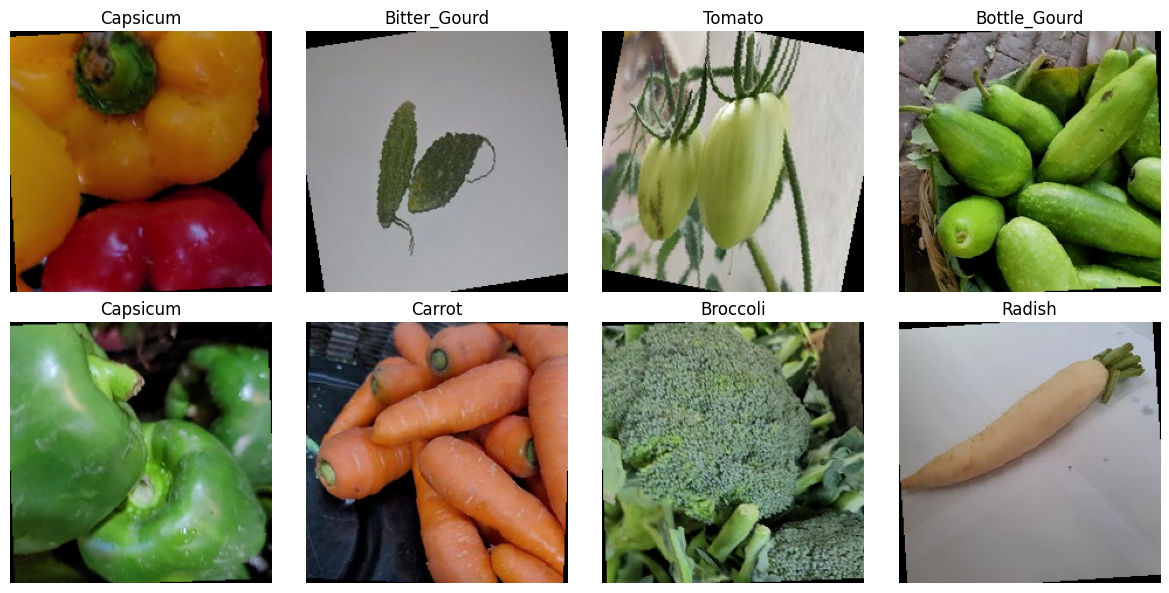

In [6]:
def denormalize(t):
    img = t.numpy().transpose(1, 2, 0)
    return np.clip(img * np.array(std) + np.array(mean), 0, 1)


preview_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
images, labels = next(iter(preview_loader))
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(images[i]))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Функции обучения и оценки

Одни и те же функции применяются к обеим моделям, чтобы сравнение было честным.

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if training:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if training:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return loss_sum / total, correct / total


def fit(model, epochs, lr, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, criterion, optimizer)
        vl, va = run_epoch(model, val_loader, criterion)
        scheduler.step()
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        if verbose:
            print(f"эпоха {ep}/{epochs} train_loss={tl:.3f} acc={ta:.3f} val_loss={vl:.3f} acc={va:.3f} ({time.time() - t0:.0f} c)")
    return history


@torch.no_grad()
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        out = model(x.to(device))
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

## 5. Модель «с нуля»

Четыре свёрточных блока вида свёртка → батч-нормализация → ReLU → подвыборка, затем классификатор.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def make_cnn():
    torch.manual_seed(SEED)
    return SimpleCNN(num_classes).to(device)


print(f"параметров в SimpleCNN: {sum(p.numel() for p in make_cnn().parameters()) / 1e6:.2f} млн")

параметров в SimpleCNN: 0.39 млн


## 6. Подбор скорости обучения по проверочной выборке

Для собственной сети перебираем несколько значений learning rate, обучаем по нескольку эпох и выбираем то значение, при котором выше accuracy на валидации.

In [9]:
search_scores = {}
for lr in LR_GRID:
    model = make_cnn()
    hist = fit(model, EPOCHS_SEARCH, lr, verbose=False)
    search_scores[lr] = max(hist["val_acc"])
    print(f"lr={lr:.0e}, val_acc={search_scores[lr]:.4f}")

best_lr = max(search_scores, key=search_scores.get)
print(f"выбранная скорость обучения: {best_lr:.0e}")

lr=3e-03, val_acc=0.8917
lr=1e-03, val_acc=0.8983
lr=3e-04, val_acc=0.8647
выбранная скорость обучения: 1e-03


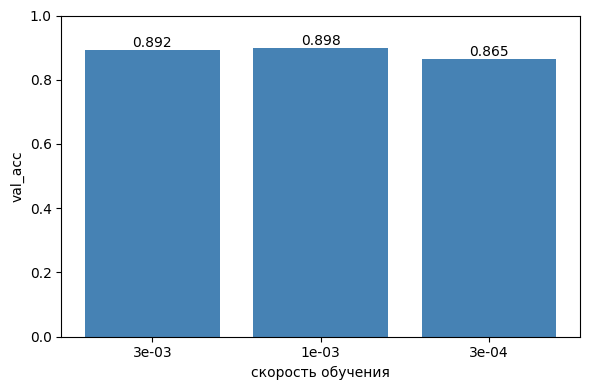

In [10]:
lrs = [f"{lr:.0e}" for lr in LR_GRID]
scores = [search_scores[lr] for lr in LR_GRID]
plt.figure(figsize=(6, 4))
plt.bar(lrs, scores, color="steelblue")
plt.ylabel("val_acc")
plt.xlabel("скорость обучения")
plt.ylim(0, 1)
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

## 7. Итоговое обучение модели «с нуля»

Обучаем сеть с выбранной скоростью обучения.

In [11]:
cnn = make_cnn()
history_cnn = fit(cnn, EPOCHS_CNN, best_lr)

эпоха 1/8 train_loss=1.041 acc=0.699 val_loss=0.660 acc=0.800 (45 c)
эпоха 2/8 train_loss=0.509 acc=0.854 val_loss=0.356 acc=0.901 (46 c)
эпоха 3/8 train_loss=0.333 acc=0.908 val_loss=0.272 acc=0.930 (44 c)
эпоха 4/8 train_loss=0.260 acc=0.926 val_loss=0.201 acc=0.943 (46 c)
эпоха 5/8 train_loss=0.193 acc=0.948 val_loss=0.167 acc=0.954 (45 c)
эпоха 6/8 train_loss=0.146 acc=0.962 val_loss=0.086 acc=0.981 (46 c)
эпоха 7/8 train_loss=0.112 acc=0.973 val_loss=0.067 acc=0.985 (45 c)
эпоха 8/8 train_loss=0.095 acc=0.980 val_loss=0.064 acc=0.985 (46 c)


## 8. Предобученная модель ResNet18

Берём ResNet18 с весами ImageNet и заменяем последний слой под 15 классов.

In [12]:
torch.manual_seed(SEED)
weights = models.ResNet18_Weights.IMAGENET1K_V1 if PRETRAINED else None
resnet = models.resnet18(weights=weights)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)
print(f"параметров в ResNet18: {sum(p.numel() for p in resnet.parameters()) / 1e6:.2f} млн")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


параметров в ResNet18: 11.18 млн


In [13]:
history_resnet = fit(resnet, EPOCHS_RESNET, LR_RESNET)

эпоха 1/3 train_loss=0.165 acc=0.966 val_loss=0.009 acc=0.999 (56 c)
эпоха 2/3 train_loss=0.009 acc=0.999 val_loss=0.004 acc=0.999 (57 c)
эпоха 3/3 train_loss=0.004 acc=1.000 val_loss=0.003 acc=1.000 (56 c)


## 9. Графики обучения

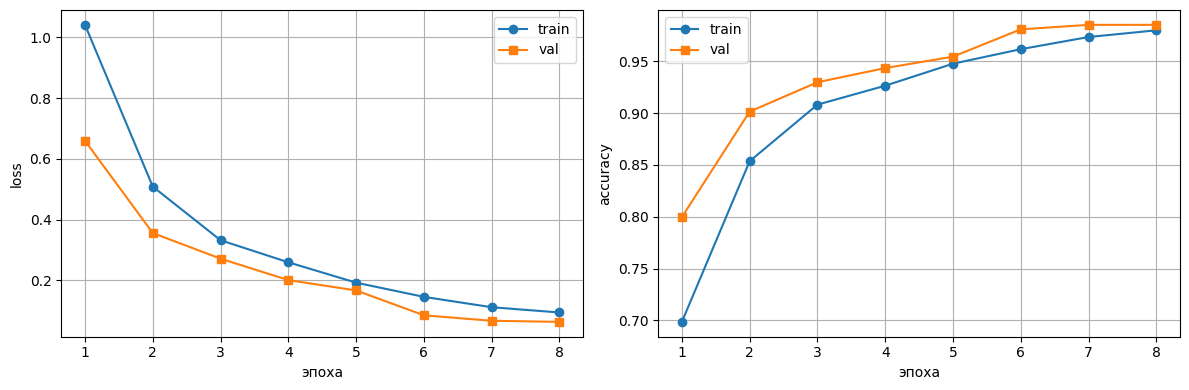

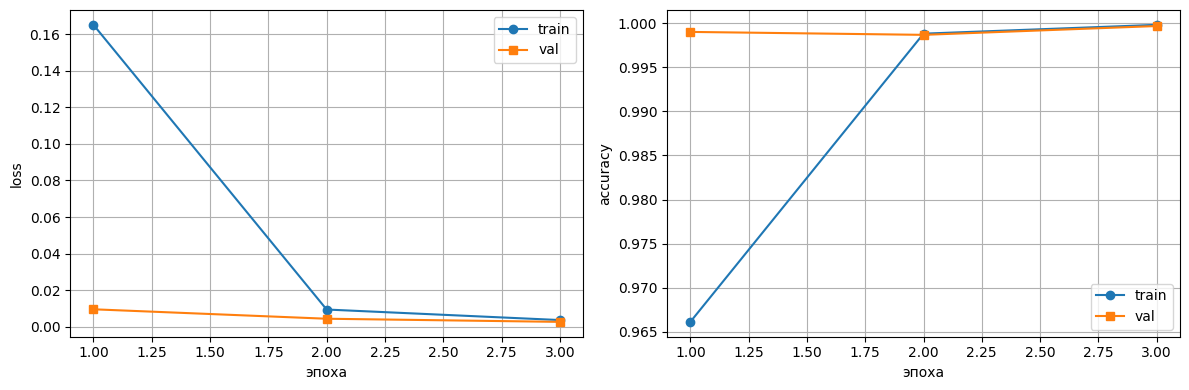

In [14]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs, history["train_loss"], "o-", label="train")
    ax[0].plot(epochs, history["val_loss"], "s-", label="val")
    ax[0].set_ylabel("loss")
    ax[0].set_xlabel("эпоха")
    ax[0].legend()
    ax[0].grid(True)
    ax[1].plot(epochs, history["train_acc"], "o-", label="train")
    ax[1].plot(epochs, history["val_acc"], "s-", label="val")
    ax[1].set_ylabel("accuracy")
    ax[1].set_xlabel("эпоха")
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()


plot_history(history_cnn)
plot_history(history_resnet)

## 10. Оценка качества на тестовой выборке

Для каждой модели считаем accuracy, отчёт по классам и матрицу ошибок.

SimpleCNN (тест)
accuracy: 0.9880
              precision    recall  f1-score   support

        Bean      0.995     0.990     0.992       200
Bitter_Gourd      0.990     0.990     0.990       200
Bottle_Gourd      1.000     0.990     0.995       200
     Brinjal      0.965     0.960     0.962       200
    Broccoli      0.995     0.990     0.992       200
     Cabbage      0.995     0.990     0.992       200
    Capsicum      1.000     0.990     0.995       200
      Carrot      1.000     1.000     1.000       200
 Cauliflower      0.995     0.975     0.985       200
    Cucumber      0.990     0.980     0.985       200
      Papaya      0.929     0.985     0.956       200
      Potato      1.000     0.995     0.997       200
     Pumpkin      0.980     0.995     0.988       200
      Radish      1.000     1.000     1.000       200
      Tomato      0.990     0.990     0.990       200

    accuracy                          0.988      3000
   macro avg      0.988     0.988     0.988   

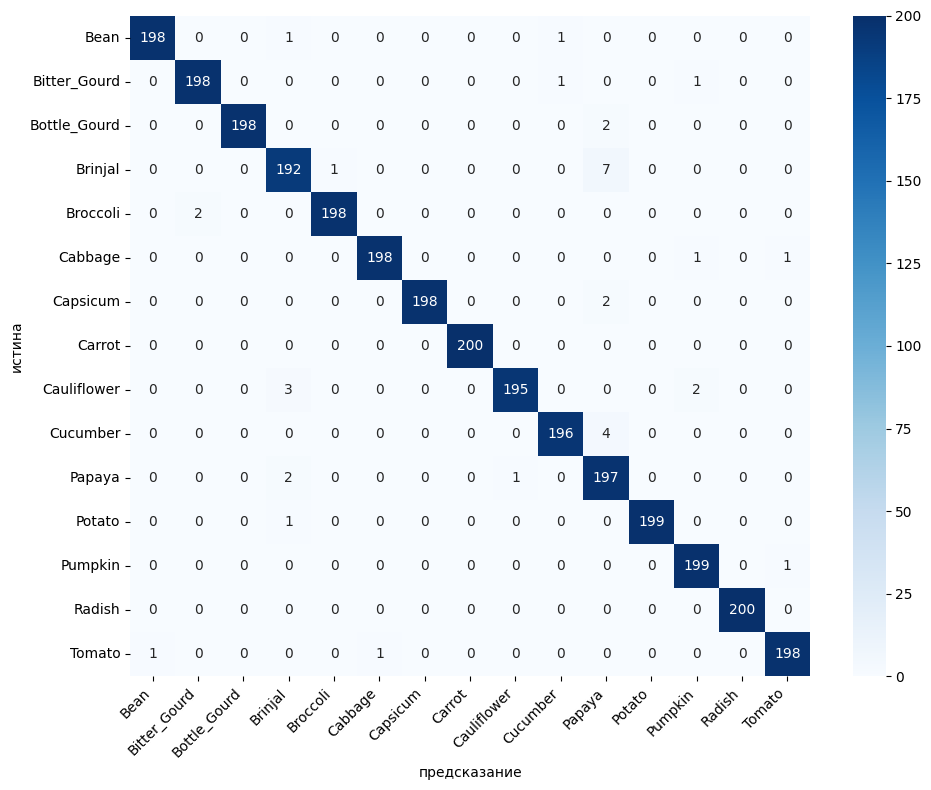

ResNet18 (тест)
accuracy: 0.9987
              precision    recall  f1-score   support

        Bean      1.000     0.995     0.997       200
Bitter_Gourd      1.000     0.990     0.995       200
Bottle_Gourd      1.000     1.000     1.000       200
     Brinjal      1.000     1.000     1.000       200
    Broccoli      1.000     1.000     1.000       200
     Cabbage      1.000     0.995     0.997       200
    Capsicum      1.000     1.000     1.000       200
      Carrot      1.000     1.000     1.000       200
 Cauliflower      0.995     1.000     0.998       200
    Cucumber      0.990     1.000     0.995       200
      Papaya      1.000     1.000     1.000       200
      Potato      1.000     1.000     1.000       200
     Pumpkin      0.995     1.000     0.998       200
      Radish      1.000     1.000     1.000       200
      Tomato      1.000     1.000     1.000       200

    accuracy                          0.999      3000
   macro avg      0.999     0.999     0.999    

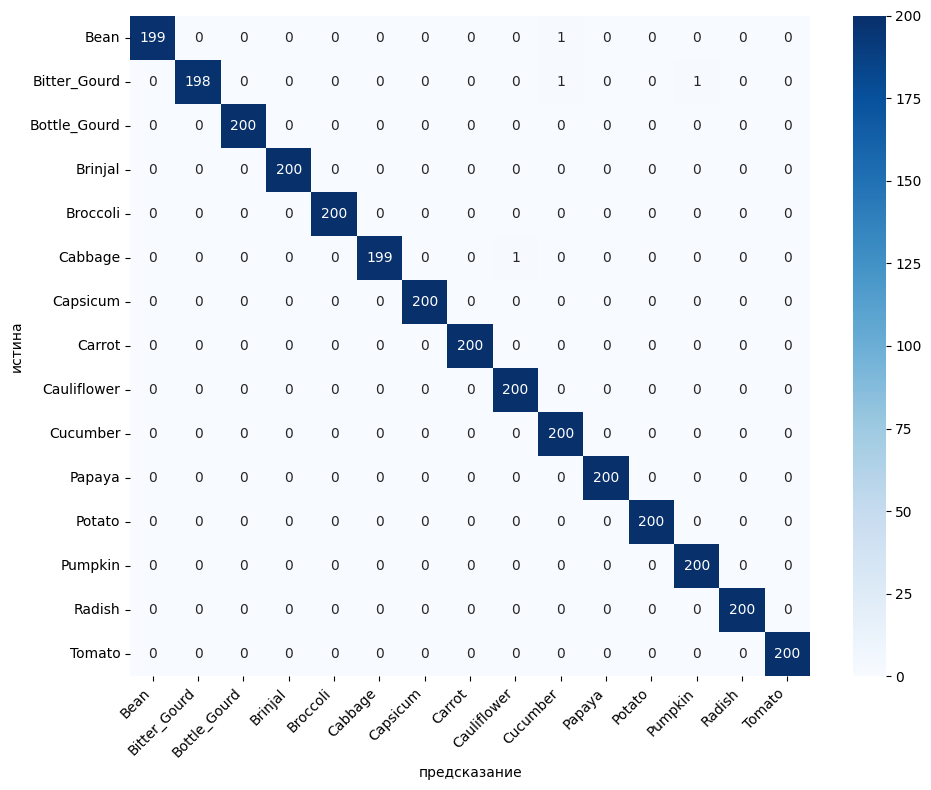

In [15]:
def evaluate(model, name, loader):
    y_true, y_pred = predict(model, loader)
    acc = accuracy_score(y_true, y_pred)
    print(name)
    print(f"accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("предсказание")
    plt.ylabel("истина")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return acc


acc_cnn = evaluate(cnn, "SimpleCNN (тест)", test_loader)
acc_resnet = evaluate(resnet, "ResNet18 (тест)", test_loader)

In [16]:
print("Сравнение точности на тестовой выборке")
print("SimpleCNN (с нуля):", round(acc_cnn, 4))
print("ResNet18 (предобученная):", round(acc_resnet, 4))

Сравнение точности на тестовой выборке
SimpleCNN (с нуля): 0.988
ResNet18 (предобученная): 0.9987


## Выводы и ответы на контрольные вопросы

### Анализ процесса обучения

По графикам видно, что предобученная ResNet18 выходит на высокую точность уже за
одну-две эпохи: перенос знаний с ImageNet даёт почти готовые признаки, и кривая
validation быстро встаёт на плато. Сеть «с нуля» учится заметно медленнее, её
кривая поднимается более полого, а разрыв между train и validation остаётся
небольшим — выраженного переобучения нет благодаря аугментации, dropout и
batch-нормализации. Скорость обучения для собственной сети выбрана по проверочной
выборке: из трёх значений (3e-3, 1e-3, 3e-4) бралось то, при котором validation
accuracy за несколько эпох оказывалась выше. Подробные метрики precision, recall и
f1 приведены на тестовой выборке, а на валидации модели контролировались по
accuracy и loss во время обучения — по этим же значениям и подбиралась скорость
обучения.

### Архитектура предобученной сети ResNet18

ResNet18 — это свёрточная сеть из 18 слоёв с весами, в основе которой лежат
остаточные блоки. Сначала идёт свёртка 7×7 и подвыборка, затем четыре группы
остаточных блоков с числом каналов 64, 128, 256 и 512, а в конце — глобальное
усреднение и полносвязный слой. Исходно сеть обучена на ImageNet и различает
1000 категорий; здесь последний слой заменён на 15 выходов под наши классы овощей.

Главная особенность — остаточная связь. Блок учит не само преобразование, а
поправку к входу, и на выходе складывает её с входным сигналом. Благодаря этому
градиент свободно доходит до ранних слоёв, и глубокую сеть удаётся обучить без
затухания градиентов. Всего в ResNet18 около 11,7 миллиона параметров.

### Как работает модель и какие у неё параметры

Сеть ожидает на входе изображение 224×224. Первый слой — свёртка 7×7 с шагом 2 и
подвыборка, которые быстро уменьшают разрешение. Дальше идут четыре стадии, в
каждой по два базовых блока со свёртками 3×3; число каналов растёт по стадиям как
64, 128, 256 и 512, а на границе стадий шаг 2 уменьшает карту признаков, при этом
в остаточной связи стоит свёртка 1×1 для согласования размерностей. После
последней стадии глобальное усреднение сворачивает карту в вектор из 512 чисел,
который полносвязный слой переводит в оценки классов. В нашей задаче этот слой
заменён с 512→1000 на 512→15, а все остальные веса взяты с ImageNet и дообучены.
Дообучение шло с оптимизатором Adam, скоростью обучения 1e-4, косинусным
расписанием и кросс-энтропией в качестве функции потерь. Такой перенос знаний даёт
высокую точность даже за несколько эпох.

### Чем свёрточная сеть отличается от полносвязной

Свёрточный нейрон смотрит только на небольшой участок изображения, тогда как
нейрон полносвязного слоя связан со всеми входами сразу. Один и тот же фильтр
применяется по всему изображению, поэтому весов нужно во много раз меньше: для
картинки 224×224×3 полносвязный слой потребовал бы сотни миллионов параметров
только на входе. Свёртка распознаёт признак независимо от его положения и
сохраняет двумерную структуру изображения, а полносвязная сеть вытягивает
картинку в один вектор и теряет соседство пикселей. Поэтому на изображениях
свёрточная сеть учится быстрее, требует меньше данных и работает точнее. Это
видно и по результатам: предобученная ResNet18 заметно опережает простую сеть,
обученную с нуля.